# Confidence Intervals and Sampling Uncertainty

When we estimate a metric from a sample, we rarely obtain the exact population value.  
Instead, our estimates fluctuate because of **random sampling**.

This uncertainty can be expressed using **confidence intervals**.  
A **95% confidence interval** provides a range of values that is likely to contain the true population parameter.

---

## Simulation Setup
- True population conversion rate: **12%**  
- Population size: **100,000 observations**  
- Repeated random samples drawn from the population  
- Each sample produces an estimated conversion rate  

By repeating this process many times, we observe the **sampling distribution of the sample mean**.  
The width of the confidence interval depends on the **standard error**, which decreases as sample size increases:



\[
SE = \sqrt{\frac{p(1-p)}{n}}
\]



Where:  
- \(p\) = true proportion  
- \(n\) = sample size  

---

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from src.utils import sample_means, confidence_interval, set_seed
#Set seed for reproducibility
set_seed(42)

In [18]:
true_rate = 0.12
population_size = 100000
population = np.random.binomial(1, true_rate, population_size)

## What the Plots Show
Each subplot corresponds to a different **sample size**.

- **Histogram** → distribution of sample mean estimates  
- **Red dashed lines** → simulated 95% confidence interval  
- **Blue dotted lines** → theoretical confidence interval  
- **Green line** → true population conversion rate


As the sample size grows:
- The sampling distribution becomes narrower  
- The standard error decreases  
- The confidence interval becomes tighter  

This demonstrates why **larger samples produce more reliable estimates**.

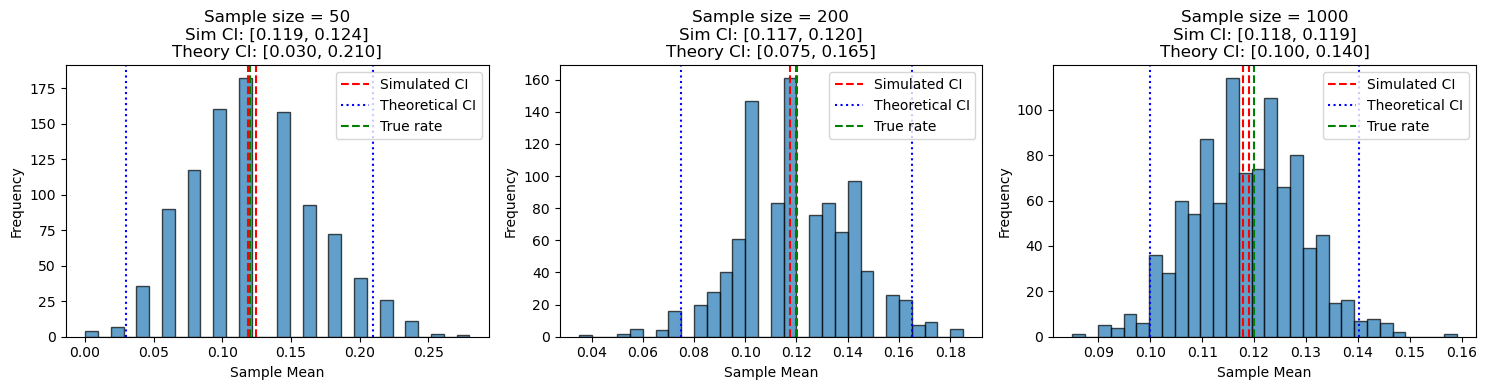

In [19]:
sample_sizes = [50, 200, 1000]
n_samples = 1000

plt.figure(figsize=(15,4))
for i, sample_size in enumerate(sample_sizes, 1):
    # Draw sample means
    means = sample_means(population, sample_size, n_samples=n_samples)
    
    # Compute simulated CI
    ci_low, ci_high = confidence_interval(means, confidence=0.95)
    
    # Compute theoretical SE and CI
    se_theoretical = np.sqrt(true_rate * (1 - true_rate) / sample_size)
    z = 1.96  # for 95% confidence
    ci_low_theory = true_rate - z * se_theoretical
    ci_high_theory = true_rate + z * se_theoretical
    
    # Plot histogram
    plt.subplot(1, len(sample_sizes), i)
    plt.hist(means, bins=30, edgecolor="black", alpha=0.7)
    
    # Overlay simulated CI bounds
    plt.axvline(ci_low, color='red', linestyle='dashed', label="Simulated CI")
    plt.axvline(ci_high, color='red', linestyle='dashed')
    
    # Overlay theoretical CI bounds
    plt.axvline(ci_low_theory, color='blue', linestyle='dotted', label="Theoretical CI")
    plt.axvline(ci_high_theory, color='blue', linestyle='dotted')
    
    # True rate line
    plt.axvline(true_rate, color='green', linestyle='dashed', label="True rate")
    
    plt.title(f"Sample size = {sample_size}\n"
              f"Sim CI: [{ci_low:.3f}, {ci_high:.3f}]\n"
              f"Theory CI: [{ci_low_theory:.3f}, {ci_high_theory:.3f}]")
    plt.xlabel("Sample Mean")
    plt.ylabel("Frequency")
    plt.legend()

plt.tight_layout()
plt.show()

### Key Takeaway

Two experiments measuring the same metric will rarely produce identical results.

This happens because every estimate is affected by **sampling variability**.

Confidence intervals help quantify this uncertainty and provide a range of plausible values for the true parameter.

In practice, this is why data scientists rely on confidence intervals when interpreting:

- model evaluation metrics
- A/B testing results
- experiment outcomes